# Stage 4 — Advanced Evaluation & Statistical Analysis

| # | Section | Purpose |
|---|---------|----------|
| 1 | Setup & Load Blind Test | Imports, GPU, paths, helpers, load test data |
| 2 | Dual-Threshold Comparison | Metrics at t=0.50 vs F2-optimal (screening) |
| 3 | Bootstrap 95% CI | Confidence intervals for AUC, Recall, F1 |
| 4 | Probability Calibration | Reliability diagram, Brier score, ECE |
| 5 | Ensemble vs Single-Best | Average 5-fold probabilities on blind test |
| 6 | Embedding Quality | Centroid distance, logistic regression on 256-D |

**Pre-requisite:** Run `stage4_final_model_evaluation.ipynb` first (needs trained models + `ImgFeatures_Stage4.csv`).

---
## 1. Setup & Load Blind Test Data

In [1]:
%matplotlib inline

import os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── GPU memory growth — MUST come before any TF/Keras import that touches GPU
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Memory growth enabled on {len(gpus)} GPU(s)')

# ── Use float32 for inference (mixed_float16 causes NaN/Inf in sigmoid) ───────
tf.keras.mixed_precision.set_global_policy('float32')
print(f'Precision policy: {tf.keras.mixed_precision.global_policy().name}')

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, brier_score_loss
)

import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {len(gpus)} device(s)')

Memory growth enabled on 1 GPU(s)
Precision policy: float32
TensorFlow: 2.10.0
GPU: 1 device(s)


In [2]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
STAGE4_DIR   = r'C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4'
MODELS_DIR   = os.path.join(STAGE4_DIR, 'models')
FOLDS_DIR    = os.path.join(STAGE4_DIR, 'Folds')
PLOTS_DIR    = os.path.join(STAGE4_DIR, 'plots')
DATA_OUT_DIR = os.path.join(STAGE4_DIR, 'data')
CSV_PATH     = os.path.join(DATA_OUT_DIR, 'ImgFeatures_Stage4.csv')

os.makedirs(PLOTS_DIR, exist_ok=True)

# ─── CONSTANTS ────────────────────────────────────────────────────────────────
NUM_FOLDS  = 5
IMG_SIZE   = (224, 224)
VGG_MEAN   = [93.5940, 104.7624, 129.1863]
SEED       = 42

np.random.seed(SEED)
print('Paths ready.')

Paths ready.


In [3]:
# ─── HELPER FUNCTIONS (same as eval notebook) ────────────────────────────────

def process_eval_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img[..., ::-1]                          # RGB → BGR
    img = tf.cast(img, tf.float32) - VGG_MEAN     # mean subtraction
    target = 1.0 - tf.cast(label, tf.float32)     # Autistic=1, Non_Autistic=0
    return img, target


def make_eval_dataset(paths, labels, batch_size=16):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(process_eval_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(1)
    return ds


def run_inference(model, dataset):
    y_true_list, y_prob_list = [], []
    for imgs, labels in dataset:
        probs = model(imgs, training=False)
        probs = tf.cast(probs, tf.float32).numpy().flatten()
        y_prob_list.extend(probs)
        y_true_list.extend(labels.numpy().flatten())
    y_true = np.array(y_true_list, dtype=np.int32)
    y_prob = np.array(y_prob_list, dtype=np.float32)
    nan_count = np.sum(~np.isfinite(y_prob))
    if nan_count > 0:
        print(f'  WARNING: {nan_count} non-finite predictions replaced with 0.5')
        y_prob = np.where(np.isfinite(y_prob), y_prob, 0.5)
    return y_true, y_prob


def compute_f2(precision, recall):
    denom = 4.0 * precision + recall
    return 0.0 if denom == 0 else (5.0 * precision * recall) / denom


def compute_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


def full_metrics(y_true, y_prob, threshold=0.5):
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_prob = np.where(np.isfinite(y_prob), y_prob, 0.5)
    y_pred = (y_prob > threshold).astype(int)
    prec   = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    spec   = compute_specificity(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    f2_val = compute_f2(prec, rec)
    acc    = accuracy_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = auc(fpr, tpr)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return dict(
        accuracy=acc, precision=prec, recall=rec, specificity=spec,
        f1=f1, f2=f2_val, auc=auc_val,
        tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn)
    )


print('Helper functions defined.')

Helper functions defined.


In [4]:
# ─── LOAD BLIND TEST SET ─────────────────────────────────────────────────────
test_paths  = np.load(os.path.join(FOLDS_DIR, 'permanent_test_paths.npy'),  allow_pickle=True)
test_labels = np.load(os.path.join(FOLDS_DIR, 'permanent_test_labels.npy'), allow_pickle=True)

n_asd     = np.sum(test_labels == 0)   # raw: Autistic=0
n_non_asd = np.sum(test_labels == 1)

print(f'Blind test set: {len(test_paths)} images')
print(f'  Autistic     (class 1 after flip): {n_asd}')
print(f'  Non-Autistic (class 0 after flip): {n_non_asd}')

Blind test set: 392 images
  Autistic     (class 1 after flip): 195
  Non-Autistic (class 0 after flip): 197


In [5]:
# ─── RUN ALL 5 FOLDS ON BLIND TEST SET ───────────────────────────────────────
fold_probs = {}
fold_true  = None

for fold_id in range(1, NUM_FOLDS + 1):
    tf.keras.backend.clear_session()
    gc.collect()

    test_ds = make_eval_dataset(test_paths, test_labels, batch_size=16)
    model_path = os.path.join(MODELS_DIR, f'fold_{fold_id}_best.h5')
    print(f'Fold {fold_id}: loading {model_path}')

    model = load_model(model_path, compile=False)
    y_true, y_prob = run_inference(model, test_ds)

    if fold_true is None:
        fold_true = y_true
    fold_probs[fold_id] = y_prob

    m = full_metrics(y_true, y_prob, threshold=0.5)
    print(f'  AUC={m["auc"]:.4f}  Recall={m["recall"]:.4f}  F2={m["f2"]:.4f}')

    del model, test_ds
    tf.keras.backend.clear_session()
    gc.collect()

# ── Identify best fold by F2
best_fold_id = max(range(1, NUM_FOLDS + 1),
                   key=lambda f: full_metrics(fold_true, fold_probs[f], 0.5)['f2'])
print(f'\nBest fold by F2: Fold {best_fold_id}')
print('All fold probabilities cached.')

Fold 1: loading C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\models\fold_1_best.h5
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU, compute capability 8.6
  AUC=0.7141  Recall=0.4462  F2=0.4796
Fold 2: loading C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\models\fold_2_best.h5
  AUC=0.7362  Recall=0.4821  F2=0.5154
Fold 3: loading C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Stage_4\models\fold_3_best.h5
  AUC=0.7370  Recall=0.4872  F2=0.5208
Fold 4: loading C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\secto

---
## 2. Dual-Threshold Comparison Table

Two thresholds are standard and defensible:

| Threshold | Rationale |
|-----------|----------|
| **0.50** (default) | Balanced classification; minimises overall error |
| **F2-optimal** (screening) | Maximises recall-weighted F2; appropriate for clinical screening where missing ASD is costlier |

The F2-optimal threshold favours **sensitivity over specificity** — acceptable for a screening tool where a positive result leads to further assessment, not a diagnosis.

In [6]:
# ── Find F2-optimal threshold by sweeping 0.01–0.99 (fine grid) ───────────────
y_prob_best = fold_probs[best_fold_id]
y_true_bin  = fold_true

thresholds_fine = np.arange(0.01, 1.00, 0.01)
best_f2, best_t = 0.0, 0.50

for t in thresholds_fine:
    y_pred_t = (y_prob_best > t).astype(int)
    prec_t = precision_score(y_true_bin, y_pred_t, pos_label=1, zero_division=0)
    rec_t  = recall_score(y_true_bin, y_pred_t, pos_label=1, zero_division=0)
    f2_t   = compute_f2(prec_t, rec_t)
    if f2_t > best_f2:
        best_f2, best_t = f2_t, t

SCREENING_THRESHOLD = round(best_t, 2)
DEFAULT_THRESHOLD   = 0.50

print(f'F2-optimal (screening) threshold: {SCREENING_THRESHOLD}')
print(f'Default threshold:                {DEFAULT_THRESHOLD}')

F2-optimal (screening) threshold: 0.06
Default threshold:                0.5


In [7]:
# ── Build side-by-side comparison table ────────────────────────────────────────
rows = []
for label, t in [('Default (0.50)', DEFAULT_THRESHOLD),
                 (f'Screening (F2-optimal = {SCREENING_THRESHOLD})', SCREENING_THRESHOLD)]:
    m = full_metrics(y_true_bin, y_prob_best, threshold=t)
    rows.append({
        'Threshold': label,
        'Accuracy':    f"{m['accuracy']:.4f}",
        'Precision':   f"{m['precision']:.4f}",
        'Recall (Sens)': f"{m['recall']:.4f}",
        'Specificity':   f"{m['specificity']:.4f}",
        'F1':          f"{m['f1']:.4f}",
        'F2':          f"{m['f2']:.4f}",
        'AUC':         f"{m['auc']:.4f}",
        'TP': m['tp'], 'TN': m['tn'], 'FP': m['fp'], 'FN': m['fn']
    })

df_dual = pd.DataFrame(rows).set_index('Threshold')

print('='*90)
print(f'DUAL-THRESHOLD COMPARISON — Best Fold (Fold {best_fold_id}) on Blind Test Set')
print('='*90)
print(df_dual.to_string())
print('='*90)
print()
print('Interpretation:')
print('  • Default (0.50): balanced precision/recall, suitable for general classification.')
print(f'  • Screening ({SCREENING_THRESHOLD}): maximises F2 (recall-heavy), appropriate for')
print('    clinical screening where missing a true ASD case is more costly than a false alarm.')
print('    Positive predictions should be followed up with specialist assessment.')

DUAL-THRESHOLD COMPARISON — Best Fold (Fold 5) on Blind Test Set
                              Accuracy Precision Recall (Sens) Specificity      F1      F2     AUC   TP   TN   FP  FN
Threshold                                                                                                            
Default (0.50)                  0.6709    0.7292        0.5385      0.8020  0.6195  0.5682  0.7626  105  158   39  90
Screening (F2-optimal = 0.06)   0.6250    0.5723        0.9744      0.2792  0.7211  0.8543  0.7626  190   55  142   5

Interpretation:
  • Default (0.50): balanced precision/recall, suitable for general classification.
  • Screening (0.06): maximises F2 (recall-heavy), appropriate for
    clinical screening where missing a true ASD case is more costly than a false alarm.
    Positive predictions should be followed up with specialist assessment.


---
## 3. Bootstrap 95% Confidence Intervals

Bootstrap resampling provides distribution-free confidence intervals for key metrics.  
This is **essential for thesis/viva defence** — point estimates alone are insufficient.

In [8]:
def bootstrap_metric(y_true, y_prob, metric_fn, n_boot=2000, seed=42):
    """
    Bootstrap a metric function.
    metric_fn(y_true, y_prob) -> float
    Returns: (point_estimate, ci_lower, ci_upper)
    """
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.randint(0, n, size=n)
        # Skip degenerate samples (only one class)
        if len(np.unique(y_true[idx])) < 2:
            scores[i] = np.nan
            continue
        scores[i] = metric_fn(y_true[idx], y_prob[idx])
    scores = scores[~np.isnan(scores)]
    point = metric_fn(y_true, y_prob)
    lo = np.percentile(scores, 2.5)
    hi = np.percentile(scores, 97.5)
    return point, lo, hi

print('Bootstrap function defined.')

Bootstrap function defined.


In [9]:
# ── Define metric lambdas (using best fold, default threshold) ─────────────────

def _auc(yt, yp):
    fpr, tpr, _ = roc_curve(yt, yp)
    return auc(fpr, tpr)

def _recall_default(yt, yp):
    return recall_score(yt, (yp > DEFAULT_THRESHOLD).astype(int), pos_label=1, zero_division=0)

def _recall_screening(yt, yp):
    return recall_score(yt, (yp > SCREENING_THRESHOLD).astype(int), pos_label=1, zero_division=0)

def _f1_default(yt, yp):
    return f1_score(yt, (yp > DEFAULT_THRESHOLD).astype(int), pos_label=1, zero_division=0)

def _precision_default(yt, yp):
    return precision_score(yt, (yp > DEFAULT_THRESHOLD).astype(int), pos_label=1, zero_division=0)

def _accuracy_default(yt, yp):
    return accuracy_score(yt, (yp > DEFAULT_THRESHOLD).astype(int))

# ── Run bootstrap (2000 iterations) ───────────────────────────────────────────
N_BOOT = 2000
y_p = y_prob_best  # best fold probs on blind test

ci_results = []
for name, fn in [
    ('AUC-ROC',                _auc),
    ('Accuracy (t=0.50)',      _accuracy_default),
    ('Precision (t=0.50)',     _precision_default),
    ('Recall (t=0.50)',        _recall_default),
    ('F1 (t=0.50)',            _f1_default),
    (f'Recall (t={SCREENING_THRESHOLD})', _recall_screening),
]:
    pt, lo, hi = bootstrap_metric(y_true_bin, y_p, fn, n_boot=N_BOOT, seed=SEED)
    ci_results.append({'Metric': name, 'Estimate': pt, '95% CI Lower': lo, '95% CI Upper': hi})
    print(f'  {name:30s}: {pt:.4f}  [{lo:.4f}, {hi:.4f}]')

df_ci = pd.DataFrame(ci_results)
print(f'\nBootstrap iterations: {N_BOOT}')
print(f'Model: Fold {best_fold_id} (best by F2)')

  AUC-ROC                       : 0.7626  [0.7178, 0.8044]
  Accuracy (t=0.50)             : 0.6709  [0.6249, 0.7143]
  Precision (t=0.50)            : 0.7292  [0.6571, 0.7968]
  Recall (t=0.50)               : 0.5385  [0.4660, 0.6033]
  F1 (t=0.50)                   : 0.6195  [0.5556, 0.6743]
  Recall (t=0.06)               : 0.9744  [0.9519, 0.9948]

Bootstrap iterations: 2000
Model: Fold 5 (best by F2)


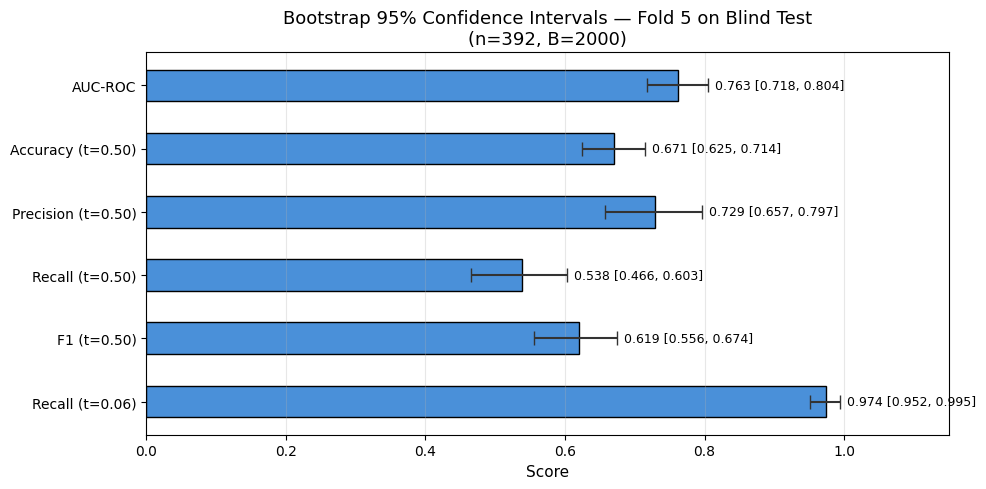

Saved: bootstrap_confidence_intervals.png


In [10]:
# ── Visualise CIs ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

metrics = df_ci['Metric'].values
estimates = df_ci['Estimate'].values
ci_lo = df_ci['95% CI Lower'].values
ci_hi = df_ci['95% CI Upper'].values
yerr = np.array([estimates - ci_lo, ci_hi - estimates])

y_pos = np.arange(len(metrics))
ax.barh(y_pos, estimates, xerr=yerr, height=0.5,
        color='#4A90D9', edgecolor='black', capsize=5, ecolor='#333')

for i, (est, lo, hi) in enumerate(zip(estimates, ci_lo, ci_hi)):
    ax.text(hi + 0.01, i, f'{est:.3f} [{lo:.3f}, {hi:.3f}]', va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(metrics, fontsize=10)
ax.set_xlabel('Score', fontsize=11)
ax.set_title(f'Bootstrap 95% Confidence Intervals — Fold {best_fold_id} on Blind Test\n'
             f'(n={len(y_true_bin)}, B={N_BOOT})', fontsize=13)
ax.set_xlim(0, 1.15)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'bootstrap_confidence_intervals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bootstrap_confidence_intervals.png')

---
## 4. Probability Calibration Analysis

A low screening threshold (e.g., 0.05) only makes clinical sense if the model's predicted probabilities are reasonably **calibrated** — i.e., when the model says "30% chance of ASD", roughly 30% of those cases should truly be ASD.

We report:
- **Reliability diagram** (calibration curve)
- **Brier score** (lower = better calibrated, range 0–1)
- **Expected Calibration Error (ECE)** (weighted mean of per-bin calibration gap)

In [11]:
# ── Calibration curve + metrics ───────────────────────────────────────────────
from sklearn.calibration import calibration_curve

n_bins = 10
prob_true, prob_pred = calibration_curve(y_true_bin, y_prob_best, n_bins=n_bins, strategy='uniform')

# Brier score
brier = brier_score_loss(y_true_bin, y_prob_best)

# Expected Calibration Error (ECE)
bin_edges = np.linspace(0, 1, n_bins + 1)
ece = 0.0
for i in range(n_bins):
    mask = (y_prob_best > bin_edges[i]) & (y_prob_best <= bin_edges[i + 1])
    if mask.sum() == 0:
        continue
    bin_acc  = y_true_bin[mask].mean()
    bin_conf = y_prob_best[mask].mean()
    ece += mask.sum() * abs(bin_acc - bin_conf)
ece /= len(y_prob_best)

print(f'Brier Score : {brier:.4f}  (lower is better; perfect = 0.0)')
print(f'ECE         : {ece:.4f}  (lower is better; perfect = 0.0)')

Brier Score : 0.2111  (lower is better; perfect = 0.0)
ECE         : 0.0982  (lower is better; perfect = 0.0)


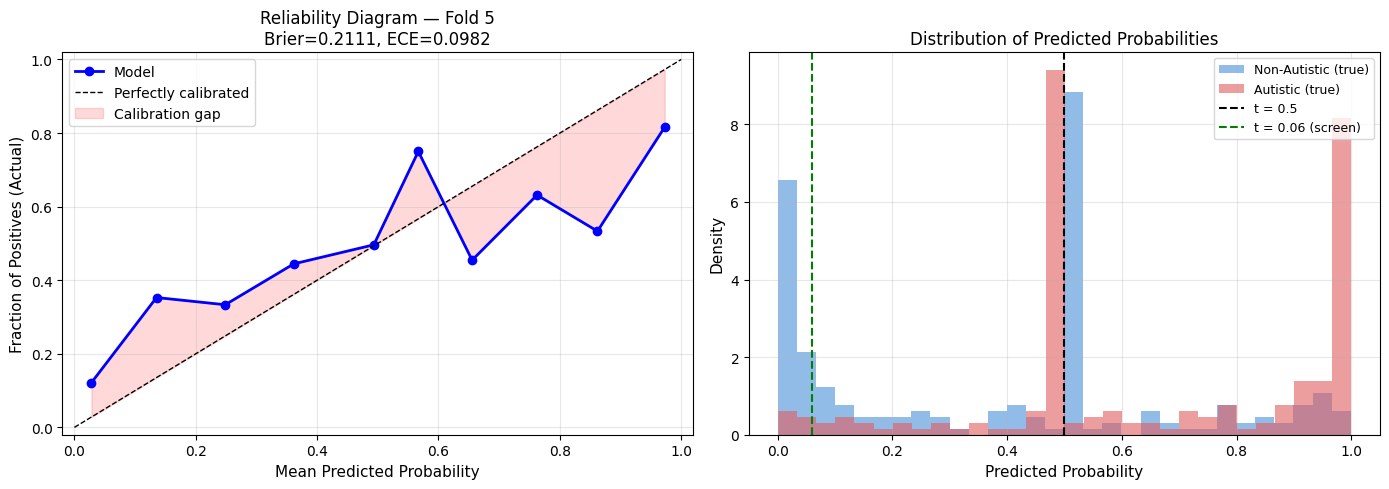

Saved: calibration_analysis.png


In [12]:
# ── Reliability diagram ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: calibration curve
ax1.plot(prob_pred, prob_true, 'b-o', markersize=6, linewidth=2, label='Model')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfectly calibrated')
ax1.fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color='red', label='Calibration gap')
ax1.set_xlabel('Mean Predicted Probability', fontsize=11)
ax1.set_ylabel('Fraction of Positives (Actual)', fontsize=11)
ax1.set_title(f'Reliability Diagram — Fold {best_fold_id}\n'
              f'Brier={brier:.4f}, ECE={ece:.4f}', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(-0.02, 1.02)

# Right: histogram of predicted probabilities
ax2.hist(y_prob_best[y_true_bin == 0], bins=30, alpha=0.6, color='#4A90D9',
         label='Non-Autistic (true)', density=True)
ax2.hist(y_prob_best[y_true_bin == 1], bins=30, alpha=0.6, color='#E05C5C',
         label='Autistic (true)', density=True)
ax2.axvline(DEFAULT_THRESHOLD, color='black', ls='--', lw=1.5, label=f't = {DEFAULT_THRESHOLD}')
ax2.axvline(SCREENING_THRESHOLD, color='green', ls='--', lw=1.5, label=f't = {SCREENING_THRESHOLD} (screen)')
ax2.set_xlabel('Predicted Probability', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Distribution of Predicted Probabilities', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'calibration_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: calibration_analysis.png')

**Interpretation guide:**

- If the blue curve hugs the diagonal → probabilities are well-calibrated.
- If it bows above the diagonal → model underestimates positive probability (under-confident).
- If it bows below → model overestimates (over-confident).
- **Brier < 0.25** is generally acceptable; **ECE < 0.10** is good.
- The right histogram shows class-separation: well-separated peaks suggest the model is discriminative.

---
## 5. Ensemble vs Single-Best on Blind Test

Ensembling all 5 folds (averaging predicted probabilities) typically boosts performance with no retraining.  
We compare: **single best fold** vs **5-fold ensemble**.

In [13]:
# ── Ensemble: average probabilities across all 5 folds ─────────────────────────
ensemble_probs = np.mean([fold_probs[f] for f in range(1, NUM_FOLDS + 1)], axis=0)

print(f'Ensemble probability range: [{ensemble_probs.min():.4f}, {ensemble_probs.max():.4f}]')
print(f'Ensemble mean probability : {ensemble_probs.mean():.4f}')

Ensemble probability range: [0.0001, 0.9998]
Ensemble mean probability : 0.4999


In [14]:
# ── Compare single-best vs ensemble at both thresholds ────────────────────────
comparison_rows = []

for model_label, probs in [(f'Single Best (Fold {best_fold_id})', y_prob_best),
                            ('Ensemble (5-fold avg)', ensemble_probs)]:
    for t_label, t in [('t=0.50', DEFAULT_THRESHOLD),
                       (f't={SCREENING_THRESHOLD}', SCREENING_THRESHOLD)]:
        m = full_metrics(y_true_bin, probs, threshold=t)
        comparison_rows.append({
            'Model': model_label,
            'Threshold': t_label,
            'Accuracy':    round(m['accuracy'], 4),
            'Precision':   round(m['precision'], 4),
            'Recall':      round(m['recall'], 4),
            'Specificity': round(m['specificity'], 4),
            'F1':          round(m['f1'], 4),
            'F2':          round(m['f2'], 4),
            'AUC':         round(m['auc'], 4),
        })

df_compare = pd.DataFrame(comparison_rows)

print('='*100)
print('SINGLE-BEST vs ENSEMBLE — Blind Test Set')
print('='*100)
print(df_compare.to_string(index=False))
print('='*100)

SINGLE-BEST vs ENSEMBLE — Blind Test Set
                Model Threshold  Accuracy  Precision  Recall  Specificity     F1     F2    AUC
 Single Best (Fold 5)    t=0.50    0.6709     0.7292  0.5385       0.8020 0.6195 0.5682 0.7626
 Single Best (Fold 5)    t=0.06    0.6250     0.5723  0.9744       0.2792 0.7211 0.8543 0.7626
Ensemble (5-fold avg)    t=0.50    0.6684     0.7444  0.5077       0.8274 0.6037 0.5422 0.7641
Ensemble (5-fold avg)    t=0.06    0.5791     0.5424  0.9846       0.1777 0.6995 0.8466 0.7641


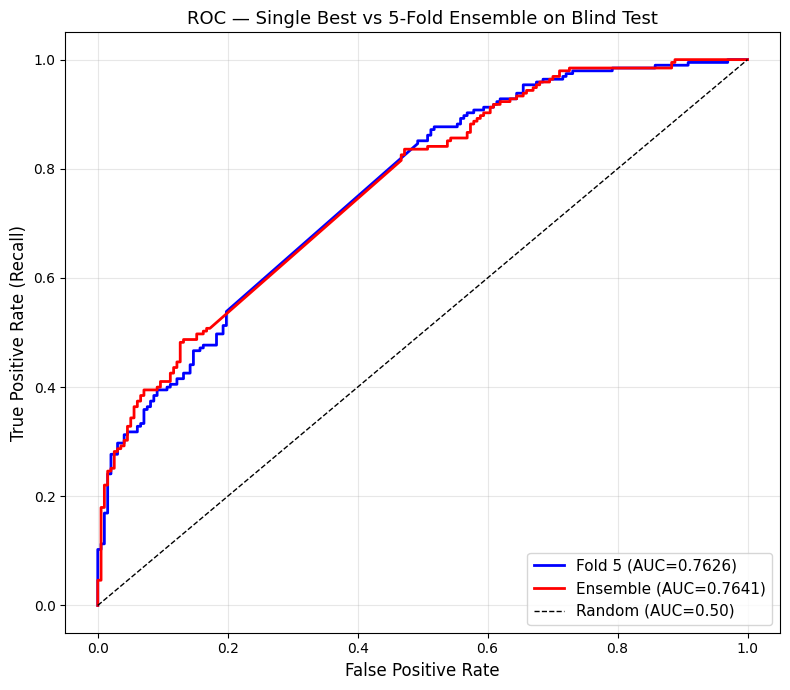

AUC improvement (ensemble − single): +0.0015
Saved: roc_single_vs_ensemble.png


In [15]:
# ── ROC comparison: single-best vs ensemble ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

fpr_s, tpr_s, _ = roc_curve(y_true_bin, y_prob_best)
auc_s = auc(fpr_s, tpr_s)
ax.plot(fpr_s, tpr_s, 'b-', lw=2, label=f'Fold {best_fold_id} (AUC={auc_s:.4f})')

fpr_e, tpr_e, _ = roc_curve(y_true_bin, ensemble_probs)
auc_e = auc(fpr_e, tpr_e)
ax.plot(fpr_e, tpr_e, 'r-', lw=2, label=f'Ensemble (AUC={auc_e:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC — Single Best vs 5-Fold Ensemble on Blind Test', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_single_vs_ensemble.png'), dpi=150)
plt.show()

delta = auc_e - auc_s
print(f'AUC improvement (ensemble − single): {delta:+.4f}')
print('Saved: roc_single_vs_ensemble.png')

In [16]:
# ── Bootstrap CI for ensemble AUC ─────────────────────────────────────────────
ens_auc_pt, ens_auc_lo, ens_auc_hi = bootstrap_metric(
    y_true_bin, ensemble_probs, _auc, n_boot=N_BOOT, seed=SEED
)

def _ens_recall_default(yt, yp):
    return recall_score(yt, (yp > DEFAULT_THRESHOLD).astype(int), pos_label=1, zero_division=0)

ens_rec_pt, ens_rec_lo, ens_rec_hi = bootstrap_metric(
    y_true_bin, ensemble_probs, _ens_recall_default, n_boot=N_BOOT, seed=SEED
)

print(f'Ensemble AUC    : {ens_auc_pt:.4f}  [{ens_auc_lo:.4f}, {ens_auc_hi:.4f}]')
print(f'Ensemble Recall : {ens_rec_pt:.4f}  [{ens_rec_lo:.4f}, {ens_rec_hi:.4f}]  (t=0.50)')

Ensemble AUC    : 0.7641  [0.7194, 0.8059]
Ensemble Recall : 0.5077  [0.4343, 0.5714]  (t=0.50)


---
## 6. Embedding Quality — Quantitative Analysis

Beyond t-SNE visualisation, we quantify whether the 256-D feature vectors carry discriminative signal:

1. **Class centroid distance** (Euclidean + cosine) in 256-D space  
2. **Logistic Regression on embeddings** — if a simple linear model achieves high AUC, the Stage 4 representation is genuinely informative (the head isn't doing all the work)

In [17]:
# ── Load embeddings ───────────────────────────────────────────────────────────
df_emb = pd.read_csv(CSV_PATH)
feat_cols = [f'V_{i}' for i in range(256)]
X_emb = df_emb[feat_cols].values.astype(np.float32)
y_emb = df_emb['Actual_Label'].values.astype(int)

print(f'Embeddings loaded: {X_emb.shape}')
print(f'  Autistic (1):     {(y_emb == 1).sum()}')
print(f'  Non-Autistic (0): {(y_emb == 0).sum()}')

Embeddings loaded: (3917, 256)
  Autistic (1):     1952
  Non-Autistic (0): 1965


In [18]:
# ── Class centroid distance ───────────────────────────────────────────────────
from scipy.spatial.distance import cosine as cosine_dist

centroid_asd     = X_emb[y_emb == 1].mean(axis=0)
centroid_non_asd = X_emb[y_emb == 0].mean(axis=0)

euclidean_dist = np.linalg.norm(centroid_asd - centroid_non_asd)
cosine_d       = cosine_dist(centroid_asd, centroid_non_asd)  # 0=identical, 1=orthogonal

# Within-class spread (mean distance from centroid)
intra_asd     = np.mean(np.linalg.norm(X_emb[y_emb == 1] - centroid_asd, axis=1))
intra_non_asd = np.mean(np.linalg.norm(X_emb[y_emb == 0] - centroid_non_asd, axis=1))

# Fisher-like ratio: inter-class / avg intra-class
fisher_ratio = euclidean_dist / ((intra_asd + intra_non_asd) / 2)

print('Class Centroid Analysis (256-D Embedding Space)')
print('─' * 50)
print(f'  Euclidean distance between centroids : {euclidean_dist:.4f}')
print(f'  Cosine distance between centroids    : {cosine_d:.4f}')
print(f'  Mean intra-class distance (ASD)      : {intra_asd:.4f}')
print(f'  Mean intra-class distance (Non-ASD)  : {intra_non_asd:.4f}')
print(f'  Fisher-like ratio (inter/intra)      : {fisher_ratio:.4f}')
print()
print('Interpretation:')
print('  Fisher ratio > 1.0 → centroids are farther apart than within-class spread (good).')
print('  Fisher ratio < 1.0 → classes overlap significantly in embedding space.')

Class Centroid Analysis (256-D Embedding Space)
──────────────────────────────────────────────────
  Euclidean distance between centroids : 5.5607
  Cosine distance between centroids    : 0.0645
  Mean intra-class distance (ASD)      : 19.8344
  Mean intra-class distance (Non-ASD)  : 18.7774
  Fisher-like ratio (inter/intra)      : 0.2880

Interpretation:
  Fisher ratio > 1.0 → centroids are farther apart than within-class spread (good).
  Fisher ratio < 1.0 → classes overlap significantly in embedding space.


In [19]:
# ── Logistic Regression on 256-D embeddings ──────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=SEED, solver='lbfgs'))
])

# 5-fold cross-validated predictions on the full embedding set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_prob_lr = cross_val_predict(pipe, X_emb, y_emb, cv=cv, method='predict_proba')[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_emb, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

acc_lr  = accuracy_score(y_emb, (y_prob_lr > 0.5).astype(int))
rec_lr  = recall_score(y_emb, (y_prob_lr > 0.5).astype(int), pos_label=1, zero_division=0)
prec_lr = precision_score(y_emb, (y_prob_lr > 0.5).astype(int), pos_label=1, zero_division=0)

print('Logistic Regression on 256-D Embeddings (5-fold CV)')
print('─' * 50)
print(f'  AUC       : {auc_lr:.4f}')
print(f'  Accuracy  : {acc_lr:.4f}')
print(f'  Precision : {prec_lr:.4f}')
print(f'  Recall    : {rec_lr:.4f}')
print()
print('If AUC is high → the embeddings carry strong discriminative signal even')
print('without the neural network head. This validates the learned representation.')

Logistic Regression on 256-D Embeddings (5-fold CV)
──────────────────────────────────────────────────
  AUC       : 0.8593
  Accuracy  : 0.7769
  Precision : 0.7781
  Recall    : 0.7725

If AUC is high → the embeddings carry strong discriminative signal even
without the neural network head. This validates the learned representation.


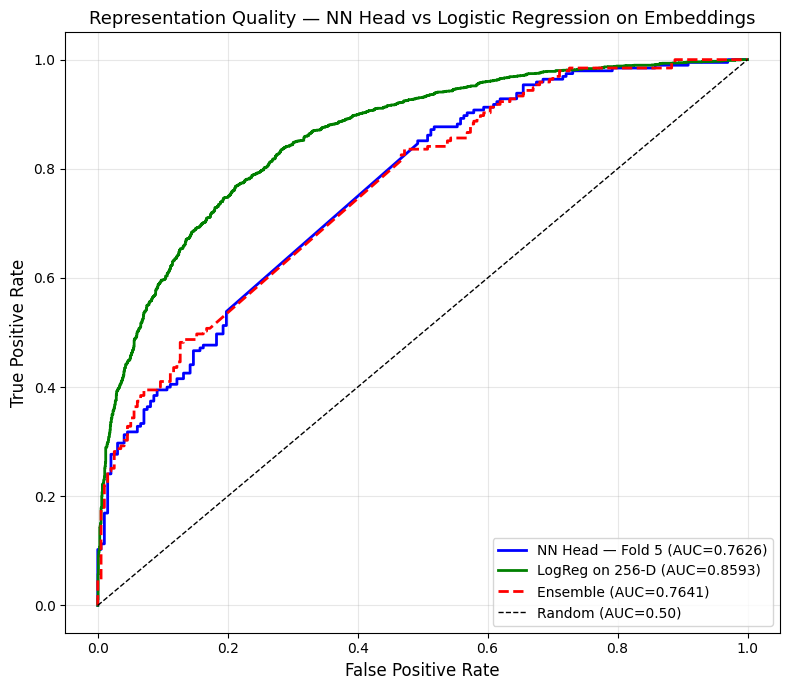

Saved: roc_nn_vs_logreg_embeddings.png


In [20]:
# ── ROC: Logistic Regression vs Neural Network Head ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

# Neural network (best fold on blind test)
ax.plot(fpr_s, tpr_s, 'b-', lw=2, label=f'NN Head — Fold {best_fold_id} (AUC={auc_s:.4f})')
# Logistic regression on embeddings (CV on full set)
ax.plot(fpr_lr, tpr_lr, 'g-', lw=2, label=f'LogReg on 256-D (AUC={auc_lr:.4f})')
# Ensemble
ax.plot(fpr_e, tpr_e, 'r--', lw=2, label=f'Ensemble (AUC={auc_e:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Representation Quality — NN Head vs Logistic Regression on Embeddings', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_nn_vs_logreg_embeddings.png'), dpi=150)
plt.show()
print('Saved: roc_nn_vs_logreg_embeddings.png')

---
## Summary

| Analysis | Key Output |
|----------|------------|
| **Dual threshold** | Metrics at t=0.50 (balanced) vs F2-optimal (screening) |
| **Bootstrap CI** | 95% confidence intervals for AUC, Recall, F1, Precision, Accuracy |
| **Calibration** | Reliability diagram, Brier score, ECE |
| **Ensemble vs Single** | ROC comparison + metrics table + ensemble bootstrap CI |
| **Embedding quality** | Centroid distance, Fisher ratio, LogReg AUC on 256-D |

All plots saved to `Stage_4/plots/`.

In [22]:
# ── Print all key metrics for summary update ──────────────────────────────────
# Re-compute silhouette & t-SNE metrics from embeddings (same data as tsne notebook)
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler as SS2
from sklearn.metrics import silhouette_score

X_sc = SS2().fit_transform(X_emb)
rng2 = np.random.default_rng(SEED)
n_samp = min(2000, len(X_sc))
idx2 = rng2.choice(len(X_sc), n_samp, replace=False)
sil_256d = silhouette_score(X_sc[idx2], y_emb[idx2], metric='euclidean', random_state=SEED)

tsne_obj = TSNE(n_components=2, perplexity=40, max_iter=1000, learning_rate='auto', init='pca', random_state=SEED, verbose=0)
X_tsne_2d = tsne_obj.fit_transform(X_sc)
sil_2d = silhouette_score(X_tsne_2d[idx2], y_emb[idx2], metric='euclidean')

print(f"Silhouette (256-D): {sil_256d:.4f}")
print(f"Silhouette (2-D t-SNE): {sil_2d:.4f}")
print(f"t-SNE KL divergence: {tsne_obj.kl_divergence_:.4f}")

Silhouette (256-D): 0.0173
Silhouette (2-D t-SNE): 0.1303
t-SNE KL divergence: 2.2749
